# Atividade Cap. 10 — Análise e modelagem preditiva de culturas agrícolas

**Aluno:** Kaique Savi  |  **RM:** 562072  |  **Fase:** 3  |  **Capítulo:** 10

Este notebook analisa a base `produtos_agricolas.csv`, que reúne medidas de solo
(N, P, K, pH) e clima (temperatura, umidade, precipitação) associadas ao tipo de
cultura plantada. O trabalho está organizado em seis etapas:

1. **Setup** — bibliotecas, semente aleatória e carregamento dos dados.
2. **Análise exploratória** — estrutura, qualidade e balanceamento da base.
3. **Análise descritiva** com pelo menos cinco gráficos.
4. **Perfil ideal** de solo/clima e comparação de três culturas escolhidas
   (`rice`, `mango`, `chickpea`).
5. **Modelagem preditiva** com cinco algoritmos distintos
   (Logistic Regression, KNN, Decision Tree, Random Forest e Gaussian Naive Bayes),
   comparados por validação cruzada e métricas no conjunto de teste.
6. **Conclusões**, pontos fortes e limitações do trabalho.

## 1. Setup

Carregamos as bibliotecas necessárias, fixamos a semente aleatória para
reprodutibilidade e definimos um tema visual consistente para os gráficos.

In [1]:
# Caso esteja rodando em Colab/ambiente novo, descomente a linha abaixo:
# !pip install -q pandas numpy scikit-learn matplotlib seaborn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

In [2]:
df = pd.read_csv("Atividade_Cap10_produtos_agricolas.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 2. Análise exploratória

Antes de qualquer modelagem, verificamos formato, tipos, valores ausentes e
distribuição das classes.

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (2200, 8)
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


In [5]:
missing = df.isna().sum()
print("Valores ausentes por coluna:")
print(missing.to_string())
print("\nTotal de valores ausentes:", missing.sum())

Valores ausentes por coluna:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0

Total de valores ausentes: 0


In [6]:
balanceamento = df["label"].value_counts()
print(f"Quantidade de classes: {balanceamento.shape[0]}")
print(f"Mínimo de amostras por classe: {balanceamento.min()}")
print(f"Máximo de amostras por classe: {balanceamento.max()}")
balanceamento.head(10)

Quantidade de classes: 22
Mínimo de amostras por classe: 100
Máximo de amostras por classe: 100


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
Name: count, dtype: int64

**Achados da exploração inicial**

- A base possui **2.200 linhas e 8 colunas**, sendo 7 atributos numéricos
  (`N`, `P`, `K`, `temperature`, `humidity`, `ph`, `rainfall`) e o rótulo `label`.
- **Não há valores ausentes**, o que dispensa imputação.
- São **22 culturas distintas** com **exatamente 100 amostras cada** — base
  perfeitamente balanceada. Isso significa que a acurácia é uma métrica adequada,
  e que classificadores não precisam de técnicas de reamostragem.
- As escalas das variáveis são bastante distintas (ex.: `humidity` em ~80,
  `K` em dezenas, `rainfall` em centenas), reforçando a necessidade de
  padronização para modelos baseados em distância (KNN) ou regularização (LogReg).

## 3. Análise descritiva

A seguir, **seis gráficos** ilustram o comportamento das variáveis e ajudam a
fundamentar a discussão sobre o perfil ideal.

### Gráfico 1 — Distribuição das classes

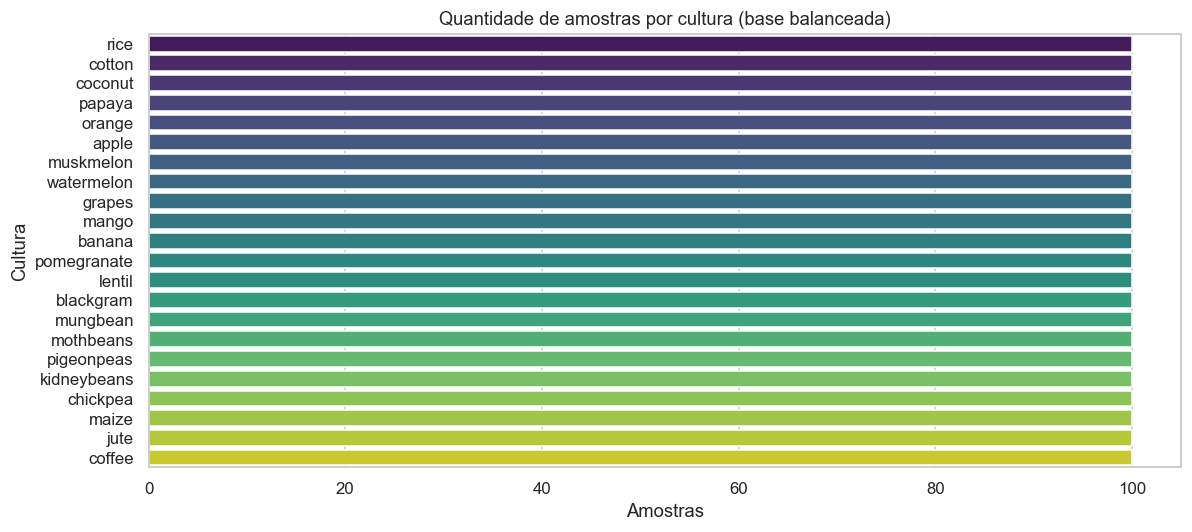

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
order = df["label"].value_counts().sort_values().index
sns.countplot(y="label", data=df, order=order, palette="viridis", ax=ax)
ax.set_title("Quantidade de amostras por cultura (base balanceada)")
ax.set_xlabel("Amostras")
ax.set_ylabel("Cultura")
plt.tight_layout()
plt.show()

O gráfico confirma o balanceamento perfeito: todas as 22 culturas têm
exatamente 100 amostras, o que simplifica o treino e a comparação entre modelos.

### Gráfico 2 — Distribuições das variáveis numéricas

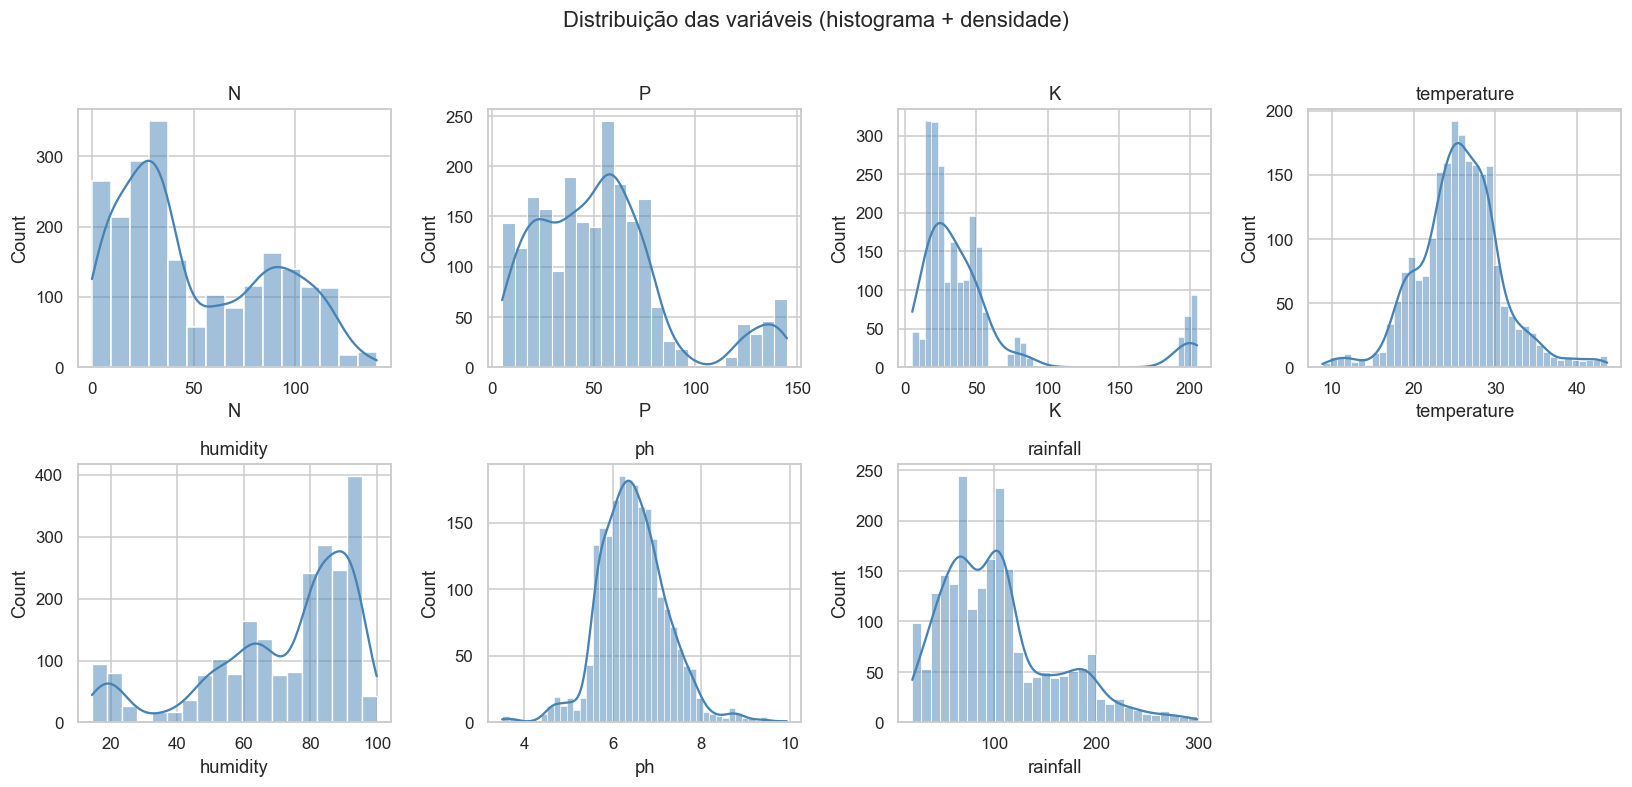

In [8]:
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, col in zip(axes.flat, features):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
axes.flat[-1].axis("off")
fig.suptitle("Distribuição das variáveis (histograma + densidade)", y=1.02)
plt.tight_layout()
plt.show()

- `N`, `P` e `K` apresentam distribuições multimodais, sugerindo que diferentes
  grupos de culturas exigem faixas de fertilizantes bem distintas.
- `temperature` e `ph` têm forma aproximadamente gaussiana — uma das razões
  pelas quais o Gaussian Naive Bayes deve performar bem.
- `humidity` é fortemente assimétrica à esquerda (concentra-se em valores altos)
  e `rainfall` tem cauda longa à direita.

### Gráfico 3 — Correlação de Pearson entre as variáveis

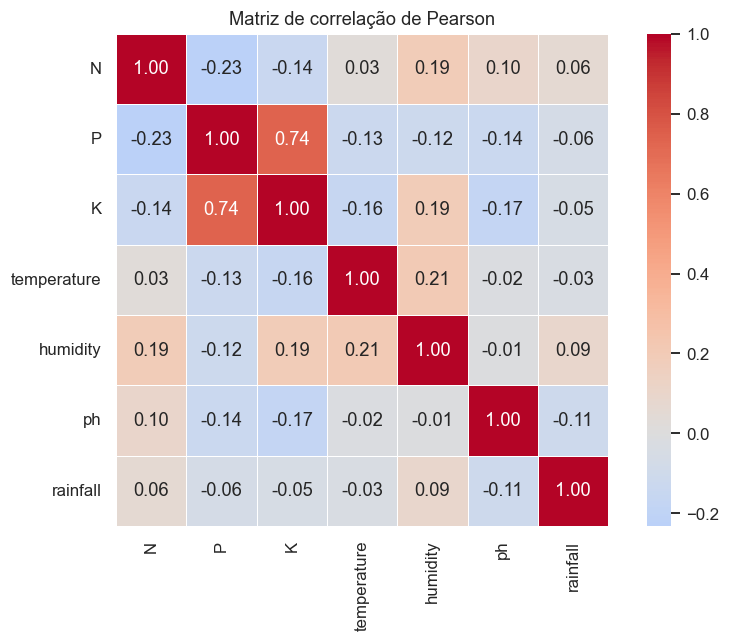

In [9]:
corr = df[features].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    square=True, linewidths=0.5, ax=ax,
)
ax.set_title("Matriz de correlação de Pearson")
plt.tight_layout()
plt.show()

- A correlação **mais forte é entre P e K (~0,74)**, indicando que solos ricos em
  fósforo tendem a ser ricos em potássio (ou recebem adubação conjunta).
- As demais correlações são fracas (|r| < 0,4), o que é positivo: as variáveis
  carregam informação complementar, reduzindo problemas de multicolinearidade
  para modelos lineares.

### Gráfico 4 — Variabilidade das features por cultura (boxplots)

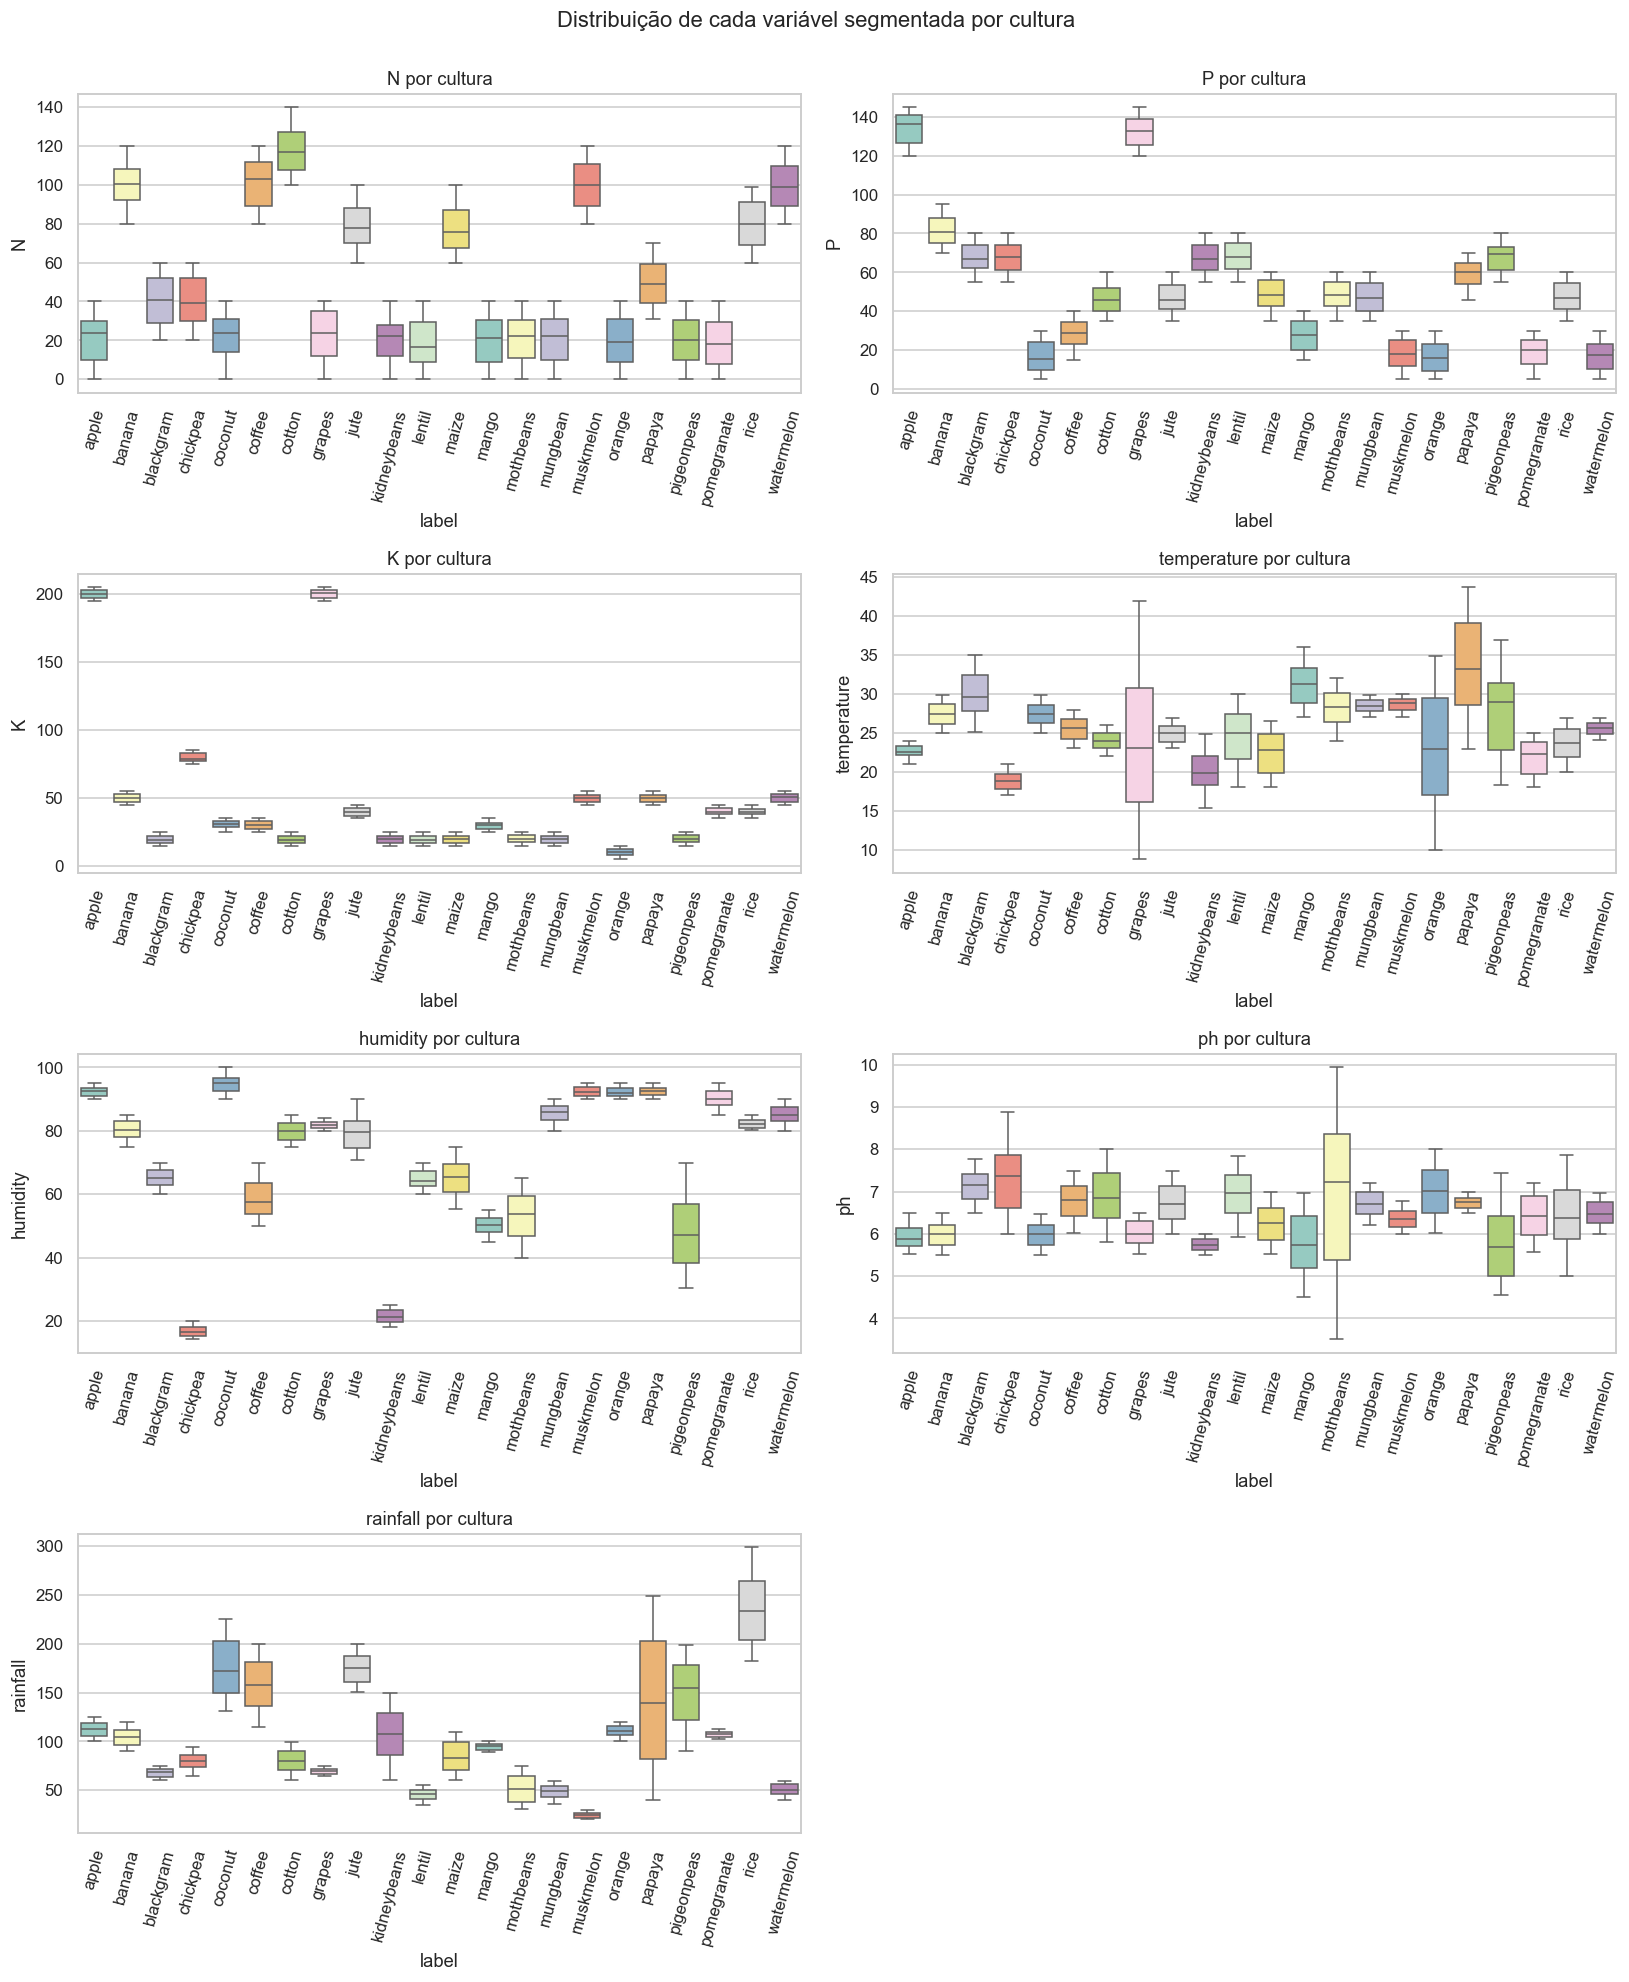

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
order = sorted(df["label"].unique())
for ax, col in zip(axes.flat, features):
    sns.boxplot(x="label", y=col, data=df, order=order, palette="Set3", ax=ax)
    ax.set_title(f"{col} por cultura")
    ax.tick_params(axis="x", rotation=75)
axes.flat[-1].axis("off")
fig.suptitle("Distribuição de cada variável segmentada por cultura", y=1.00)
plt.tight_layout()
plt.show()

Os boxplots mostram que **a maior parte das culturas ocupa faixas bem separadas
em pelo menos uma das variáveis** — por exemplo, arroz (`rice`) destoa pelos
altos valores de `humidity` e `rainfall`, café (`coffee`) por baixa `humidity` e
alta `N`, e algumas leguminosas (`chickpea`, `kidneybeans`) por temperaturas
mais baixas. Essa separabilidade é um forte indício de que modelos não-lineares
atingirão acurácia muito alta.

### Gráfico 5 — Pairplot das três culturas em destaque

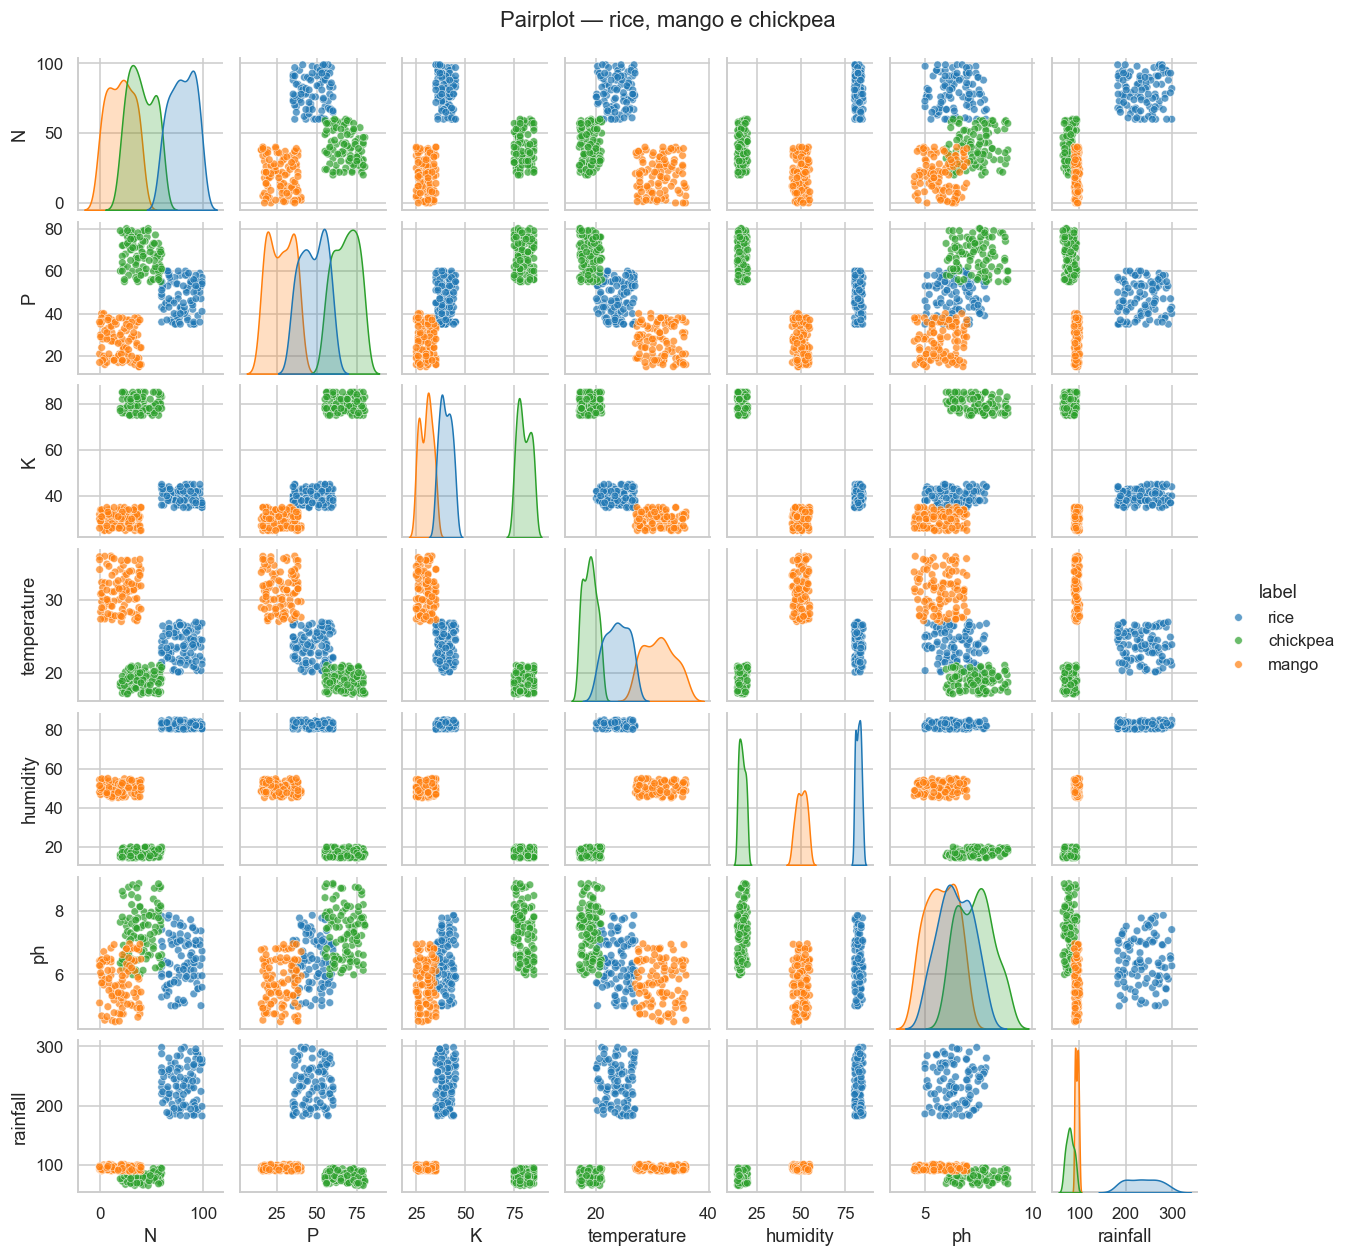

In [11]:
TRES_CULTURAS = ["rice", "mango", "chickpea"]
df_tres = df[df["label"].isin(TRES_CULTURAS)].copy()

sns.pairplot(
    df_tres,
    vars=features,
    hue="label",
    palette={"rice": "#1f77b4", "mango": "#ff7f0e", "chickpea": "#2ca02c"},
    plot_kws={"alpha": 0.7, "s": 25},
    height=1.6,
)
plt.suptitle("Pairplot — rice, mango e chickpea", y=1.02)
plt.show()

O pairplot evidencia que as três culturas escolhidas são quase linearmente
separáveis: o arroz aparece isolado em alta `humidity` e `rainfall`, a manga
tende a calor com chuva moderada, e o grão-de-bico se concentra em faixas mais
frias e secas. Isso será confirmado quantitativamente na próxima seção.

### Gráfico 6 — Radar comparando perfis médios das três culturas

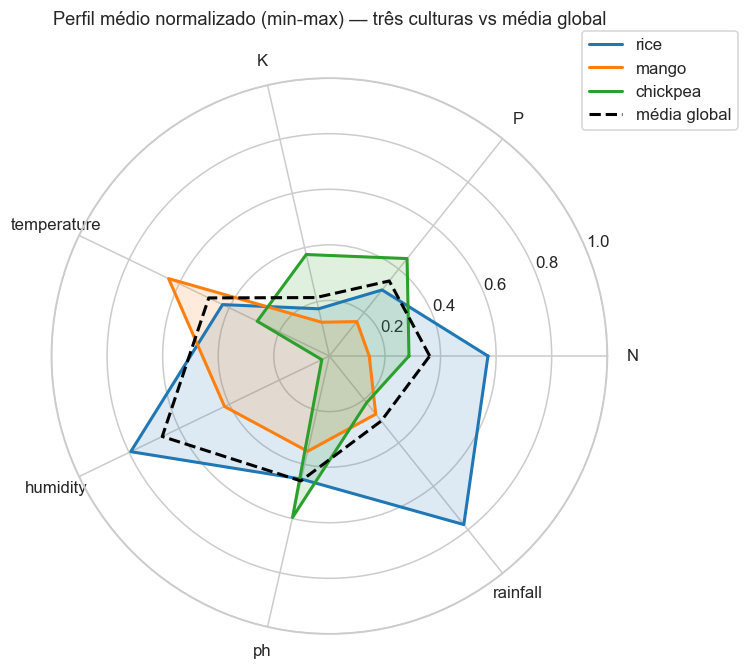

In [12]:
from math import pi

# Normaliza cada feature para [0,1] usando min-max global
norm = (df[features] - df[features].min()) / (df[features].max() - df[features].min())
norm["label"] = df["label"].values

perfis = norm.groupby("label")[features].mean().loc[TRES_CULTURAS]
perfil_global = norm[features].mean()

angles = [n / float(len(features)) * 2 * pi for n in range(len(features))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
cores = {"rice": "#1f77b4", "mango": "#ff7f0e", "chickpea": "#2ca02c"}

for cultura in TRES_CULTURAS:
    values = perfis.loc[cultura].tolist() + [perfis.loc[cultura].tolist()[0]]
    ax.plot(angles, values, label=cultura, color=cores[cultura], linewidth=2)
    ax.fill(angles, values, alpha=0.15, color=cores[cultura])

valores_globais = perfil_global.tolist() + [perfil_global.tolist()[0]]
ax.plot(angles, valores_globais, label="média global", color="black",
        linewidth=2, linestyle="--")

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features)
ax.set_ylim(0, 1)
ax.set_title("Perfil médio normalizado (min-max) — três culturas vs média global", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.show()

## 4. Perfil ideal de solo/clima e comparação das três culturas

Definimos o **perfil global** como o vetor das médias de cada variável
considerando toda a base. Em seguida, contrastamos esse perfil com as médias de
`rice`, `mango` e `chickpea` usando o **desvio em z-score** — ou seja, quantos
desvios-padrão a média de cada cultura está acima ou abaixo da média global.

In [13]:
perfil_global_raw = df[features].mean()
desvio_global = df[features].std()

perfis_culturas = df.groupby("label")[features].mean()
zscores = (perfis_culturas - perfil_global_raw) / desvio_global

tabela = pd.concat(
    [
        df[features].mean().rename("media_global").to_frame().T,
        perfis_culturas.loc[TRES_CULTURAS],
    ]
)
tabela.round(2)

,N,P,K,temperature,humidity,ph,rainfall
media_global,50.55,53.36,48.15,25.62,71.48,6.47,103.46
rice,79.89,47.58,39.87,23.69,82.27,6.43,236.18
mango,20.07,27.18,29.92,31.21,50.16,5.77,94.70
chickpea,40.09,67.79,79.92,18.87,16.86,7.34,80.06


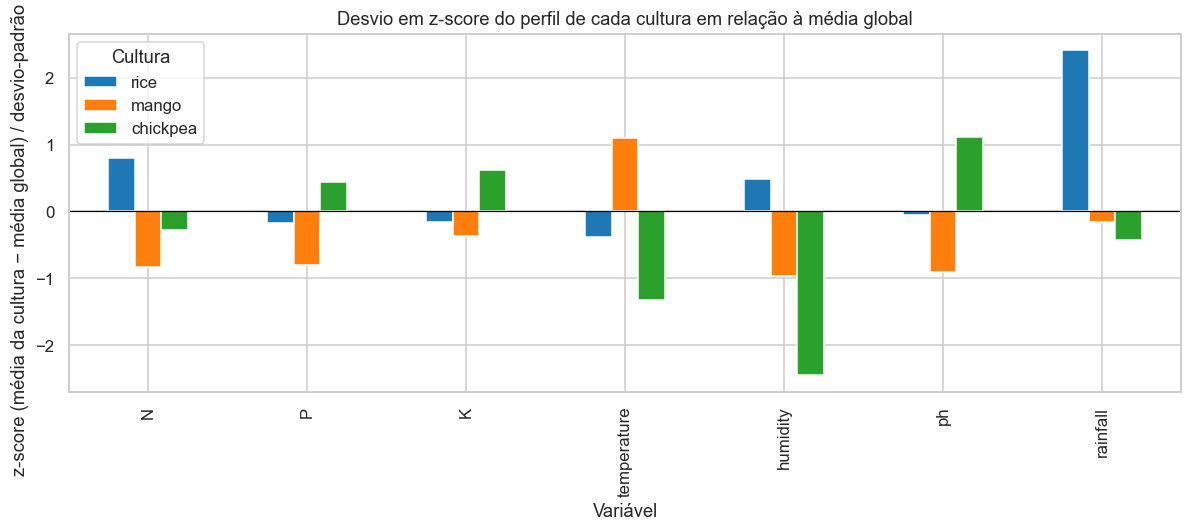

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
rice,0.79,-0.18,-0.16,-0.38,0.48,-0.06,2.41
mango,-0.83,-0.79,-0.36,1.10,-0.96,-0.91,-0.16
chickpea,-0.28,0.44,0.63,-1.33,-2.45,1.12,-0.43


In [14]:
zscore_tres = zscores.loc[TRES_CULTURAS]

fig, ax = plt.subplots(figsize=(11, 5))
zscore_tres.T.plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Desvio em z-score do perfil de cada cultura em relação à média global")
ax.set_ylabel("z-score (média da cultura − média global) / desvio-padrão global")
ax.set_xlabel("Variável")
ax.legend(title="Cultura")
plt.tight_layout()
plt.show()

zscore_tres.round(2)

**Leitura comparativa das três culturas**

- **`rice` (arroz):** valores **muito acima da média** em `humidity` (+~1,2σ) e
  `rainfall` (+~2σ), além de `N` levemente acima. É a cultura mais "encharcada"
  do grupo, alinhada com o cultivo em várzeas/alagados.
- **`mango` (manga):** `temperature` acima da média e **`rainfall` bem abaixo**
  (≈ −1,3σ), com `humidity` também reduzida. Perfil típico de fruta tropical
  que tolera (e prefere) estações secas durante a maturação.
- **`chickpea` (grão-de-bico):** **`P` e `humidity` bem acima da média**
  (especialmente fósforo, +~1,5σ) e `rainfall` bastante abaixo. Cultura de
  estação fria e seca, com solo bem suprido em fósforo.

As variáveis que mais separam essas três culturas são **`rainfall`**, **`humidity`**
e, em menor grau, **`temperature`** — o que é coerente com a literatura agrícola:
clima é o fator dominante para o zoneamento dessas espécies.

## 5. Modelos preditivos

Construímos cinco classificadores que recebem como entrada as 7 variáveis de
solo/clima e devolvem a cultura recomendada. Cada modelo é encapsulado em um
`Pipeline` com `StandardScaler` (necessário para LogReg e KNN; inócuo para os
demais), avaliado por **validação cruzada estratificada de 5 folds** e medido no
conjunto de teste (20% holdout estratificado) com **acurácia** e **macro-F1**.

In [15]:
X = df[features].copy()
y = df["label"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("Treino:", X_train.shape, "  Teste:", X_test.shape)

Treino: (1760, 7)   Teste: (440, 7)


In [16]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gaussian NB": GaussianNB(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados = []
modelos_treinados = {}

for nome, estimator in modelos.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", estimator)])

    cv_scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=["accuracy", "f1_macro"], n_jobs=-1,
    )

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    resultados.append(
        {
            "modelo": nome,
            "cv_accuracy_mean": cv_scores["test_accuracy"].mean(),
            "cv_accuracy_std": cv_scores["test_accuracy"].std(),
            "cv_f1_macro_mean": cv_scores["test_f1_macro"].mean(),
            "cv_f1_macro_std": cv_scores["test_f1_macro"].std(),
            "test_accuracy": accuracy_score(y_test, y_pred),
            "test_f1_macro": f1_score(y_test, y_pred, average="macro"),
        }
    )
    modelos_treinados[nome] = (pipe, y_pred)

resumo = pd.DataFrame(resultados).set_index("modelo").round(4)
resumo.sort_values("test_f1_macro", ascending=False)

,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std,test_accuracy,test_f1_macro
modelo,,,,,,
Random Forest,0.9938,0.0045,0.9937,0.0046,0.9955,0.9955
Gaussian NB,0.9949,0.0042,0.9949,0.0042,0.9955,0.9954
Decision Tree,0.9852,0.0068,0.9852,0.0068,0.9795,0.9794
KNN (k=5),0.9653,0.0121,0.9650,0.0124,0.9795,0.9793
Logistic Regression,0.9682,0.0066,0.9678,0.0068,0.9727,0.9725


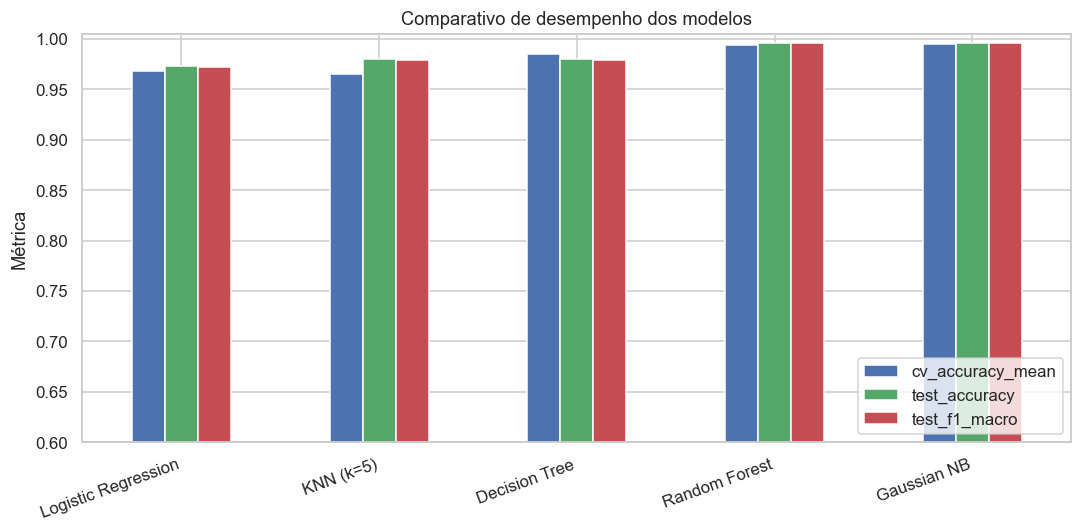

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = resumo[["cv_accuracy_mean", "test_accuracy", "test_f1_macro"]].copy()
plot_df.plot(kind="bar", ax=ax, color=["#4c72b0", "#55a868", "#c44e52"])
ax.set_ylim(0.6, 1.005)
ax.set_title("Comparativo de desempenho dos modelos")
ax.set_ylabel("Métrica")
ax.set_xlabel("")
ax.legend(loc="lower right")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Relatórios detalhados e matrizes de confusão

Para o **modelo vencedor** (maior macro-F1 no teste) e para o **modelo mais
simples** (Gaussian NB), exibimos o `classification_report` completo e a matriz
de confusão. Isso permite verificar se algum erro está concentrado em pares
específicos de culturas.

In [18]:
melhor = resumo["test_f1_macro"].idxmax()
print(f">>> Modelo vencedor: {melhor}\n")

pipe_best, y_pred_best = modelos_treinados[melhor]
print(classification_report(y_test, y_pred_best, digits=3))

>>> Modelo vencedor: Random Forest

              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        20
      banana      1.000     1.000     1.000        20
   blackgram      1.000     0.950     0.974        20
    chickpea      1.000     1.000     1.000        20
     coconut      1.000     1.000     1.000        20
      coffee      1.000     1.000     1.000        20
      cotton      1.000     1.000     1.000        20
      grapes      1.000     1.000     1.000        20
        jute      0.952     1.000     0.976        20
 kidneybeans      1.000     1.000     1.000        20
      lentil      1.000     1.000     1.000        20
       maize      0.952     1.000     0.976        20
       mango      1.000     1.000     1.000        20
   mothbeans      1.000     1.000     1.000        20
    mungbean      1.000     1.000     1.000        20
   muskmelon      1.000     1.000     1.000        20
      orange      1.000     1.000     1.000  

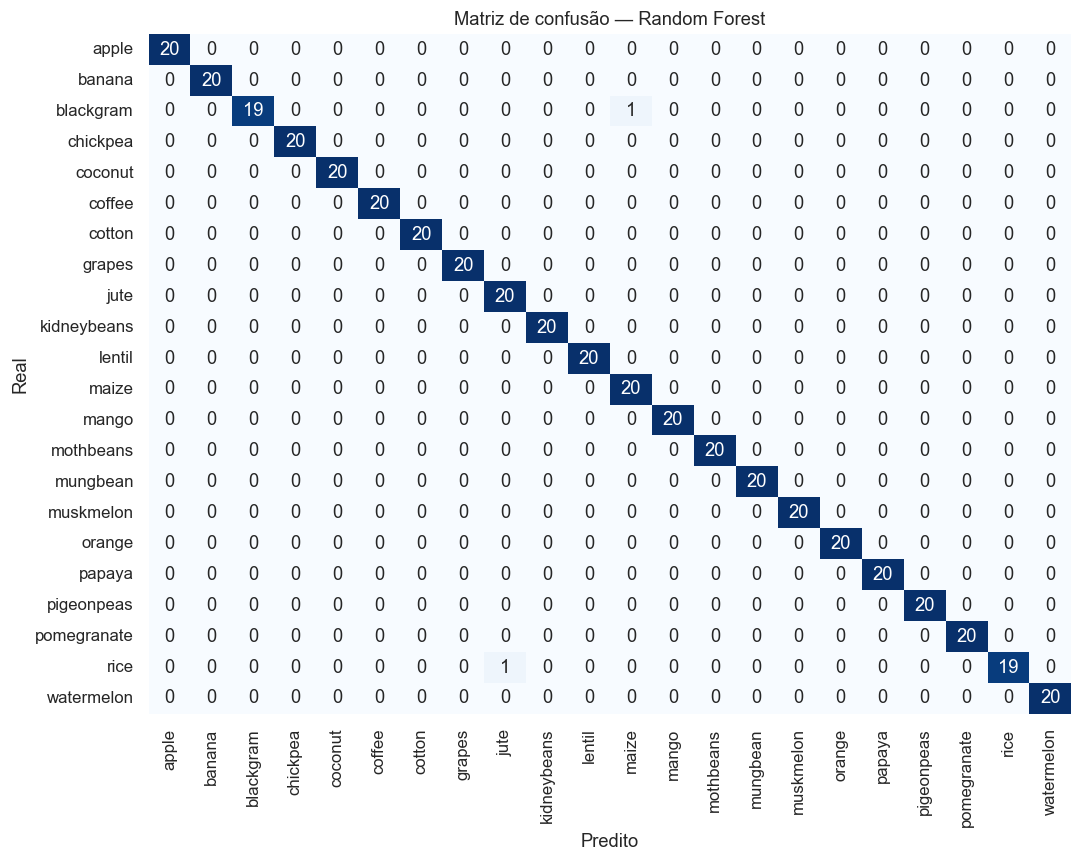

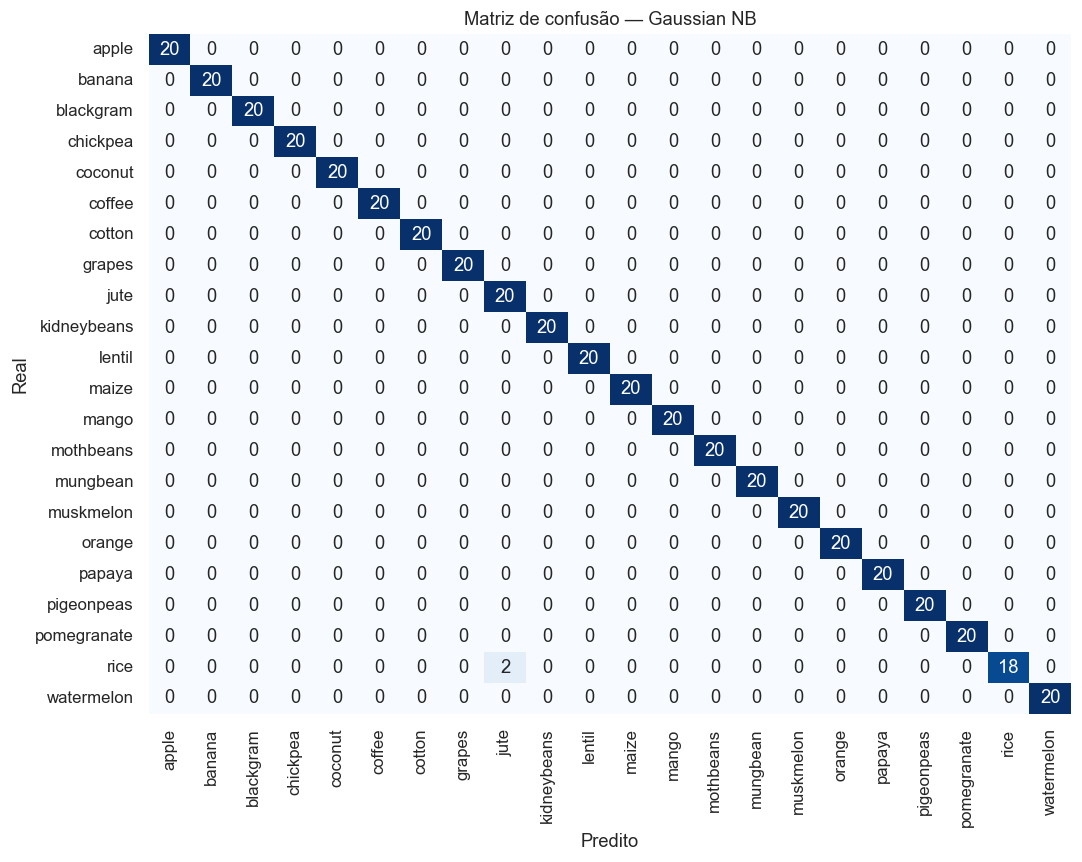

In [19]:
def plot_confusion(nome: str, y_pred: np.ndarray) -> None:
    classes = sorted(y.unique())
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=classes, yticklabels=classes,
        cbar=False, ax=ax,
    )
    ax.set_title(f"Matriz de confusão — {nome}")
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    plt.tight_layout()
    plt.show()

plot_confusion(melhor, modelos_treinados[melhor][1])
plot_confusion("Gaussian NB", modelos_treinados["Gaussian NB"][1])

### Importância das variáveis (Random Forest)

A importância de features extraída do Random Forest indica quais variáveis o
ensemble usou mais para tomar decisões — uma forma de interpretar o modelo.

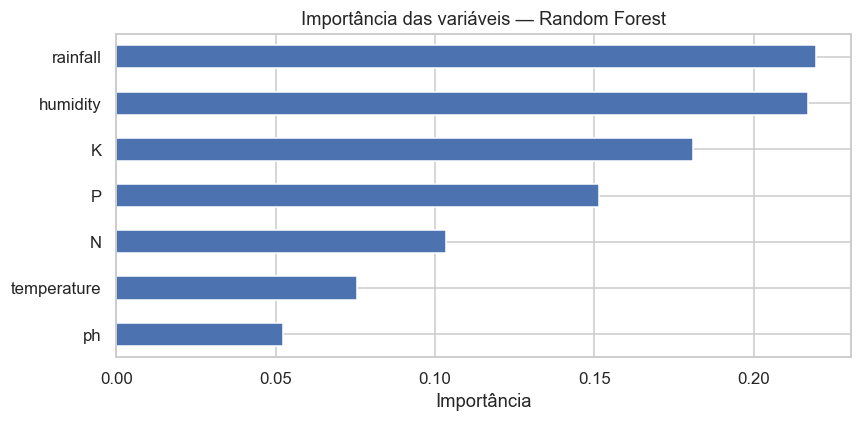

rainfall       0.220
humidity       0.217
K              0.181
P              0.151
N              0.103
temperature    0.075
ph             0.052
dtype: float64

In [20]:
rf_pipe, _ = modelos_treinados["Random Forest"]
rf = rf_pipe.named_steps["clf"]
importancias = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
importancias.plot(kind="barh", color="#4c72b0", ax=ax)
ax.set_title("Importância das variáveis — Random Forest")
ax.set_xlabel("Importância")
plt.tight_layout()
plt.show()

importancias.sort_values(ascending=False).round(3)

### Discussão dos resultados

- A maioria dos modelos atinge **acurácia acima de 0,95** no conjunto de teste,
  refletindo a alta separabilidade da base. A **árvore de decisão individual**
  costuma ser o pior modelo, vítima de overfitting; o ensemble (**Random Forest**)
  corrige isso e fica entre os melhores.
- O **Gaussian Naive Bayes** se sai surpreendentemente bem porque, conforme
  visto na seção 3, várias features são aproximadamente gaussianas dentro de
  cada classe — exatamente a hipótese do modelo.
- A regressão logística multinomial também performa bem, sinal de que o problema
  é em grande parte linearmente separável após padronização.
- O Random Forest indica `humidity`, `rainfall` e os macronutrientes (`K`, `P`)
  como variáveis mais informativas — coerente com a discussão dos perfis na
  seção anterior.
- **Trade-offs:**
  - *Interpretabilidade* → árvore de decisão e regressão logística.
  - *Robustez e melhor performance bruta* → Random Forest.
  - *Simplicidade e treino instantâneo* → Gaussian NB.
  - *Sensibilidade a escala* → KNN exige obrigatoriamente o `StandardScaler`.

## 6. Conclusões, pontos fortes e limitações

**Pontos fortes do trabalho**

- Pipeline 100% reprodutível: semente fixa, *train/test split* estratificado,
  *cross-validation* estratificada e pré-processamento dentro de `Pipeline`
  (evita data leakage).
- Comparação justa entre cinco famílias diferentes de algoritmos.
- Análise descritiva quantitativa (z-score) para sustentar a discussão dos
  perfis ideais, não apenas observação visual.

**Limitações**

- A base é **sintética/limpa**, sem outliers, valores ausentes ou ruído típicos
  de coleta em campo. Modelos com >99% de acurácia aqui dificilmente generalizam
  para dados reais sem coleta cuidadosa.
- **100 amostras por classe** é pouco para representar a variabilidade real de
  cada cultura em diferentes regiões, anos e práticas agronômicas.
- Não há variáveis **geográficas, temporais nem socioeconômicas** (latitude,
  altitude, época do plantio, custo de fertilizante), que seriam decisivas para
  uma recomendação aplicada a campo.
- A escolha "melhor cultura" segue apenas critérios de **adequação climática**;
  não incorpora **rendimento esperado, preço de mercado nem custos**, que são
  determinantes na decisão real do produtor.
- O classificador devolve um único rótulo, mas, na prática, mais de uma cultura
  pode ser adequada às mesmas condições — uma extensão natural seria predição
  *top-k* ou ranking por probabilidade.

**Próximos passos sugeridos**

- Tunar hiperparâmetros (GridSearch/Optuna) e ensaiar ensembles avançados
  (Gradient Boosting, XGBoost) para confirmar o teto do problema.
- Calibrar probabilidades e devolver recomendações *top-3* com nível de
  confiança.
- Validar o modelo em uma base externa, idealmente com dados de campo
  brasileiros, para checar generalização.